In [1]:
import numpy as np
from collections import Counter

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
#chargement de donnes
wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(124, 13)
(54, 13)


In [3]:
#boostrap
def bootstrap_sample(X, y):

    n_samples = len(X)

    indices = np.random.choice(
        n_samples,
        size=n_samples,
        replace=True
    )

    return X[indices], y[indices]

In [4]:
#creation du bagging
n_trees = 50

trees = []

for i in range(n_trees):

    X_boot, y_boot = bootstrap_sample(
        X_train,
        y_train
    )

    tree = DecisionTreeClassifier()

    tree.fit(X_boot, y_boot)

    trees.append(tree)

In [5]:
#vote majoritaire
predictions = np.array([
    tree.predict(X_test)
    for tree in trees
])

predictions = predictions.T

final_predictions = []

for sample_predictions in predictions:

    vote = Counter(sample_predictions).most_common(1)[0][0]

    final_predictions.append(vote)

final_predictions = np.array(final_predictions)

In [6]:
#evaluation
acc_bagging = accuracy_score(
    y_test,
    final_predictions
)

print("Accuracy Bagging :", acc_bagging)


Accuracy Bagging : 0.9629629629629629


In [7]:
#comparer avec seul arbre
tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

acc_tree = accuracy_score(
    y_test,
    pred_tree
)

print("Accuracy Arbre :", acc_tree)
print("Accuracy Bagging :", acc_bagging)

Accuracy Arbre : 0.9444444444444444
Accuracy Bagging : 0.9629629629629629


TP 2 : Étude de n_estimators
Cellule 8 : Importations

In [8]:
#importation
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [9]:
#test de plusieurs foret
estimators = [10, 100, 500, 1000]

results = []

for n in estimators:

    scores = []

    for seed in range(10):

        rf = RandomForestClassifier(
            n_estimators=n,
            random_state=seed
        )

        rf.fit(X_train, y_train)

        pred = rf.predict(X_test)

        acc = accuracy_score(
            y_test,
            pred
        )

        scores.append(acc)

    results.append([
        n,
        np.mean(scores),
        np.std(scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "mean_accuracy",
        "std_accuracy"
    ]
)

results_df

,n_estimators,mean_accuracy,std_accuracy
0,10,0.970370,0.022222
1,100,0.998148,0.005556
2,500,1.000000,0.000000
3,1000,1.000000,0.000000


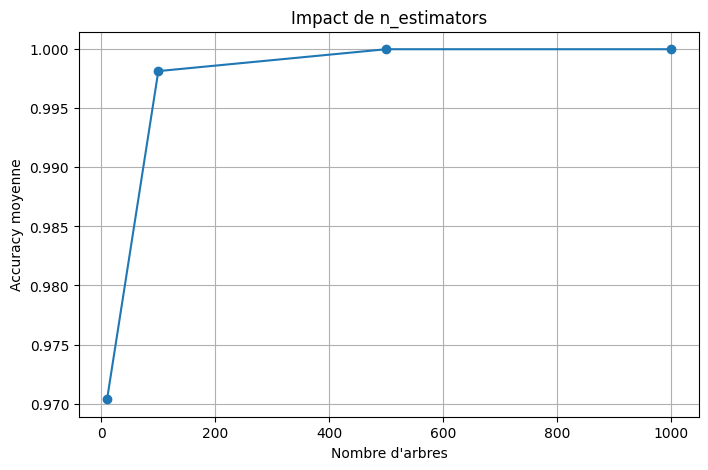

In [10]:
#graphique
plt.figure(figsize=(8,5))

plt.plot(
    results_df["n_estimators"],
    results_df["mean_accuracy"],
    marker="o"
)

plt.xlabel("Nombre d'arbres")
plt.ylabel("Accuracy moyenne")
plt.title("Impact de n_estimators")

plt.grid(True)

plt.show()

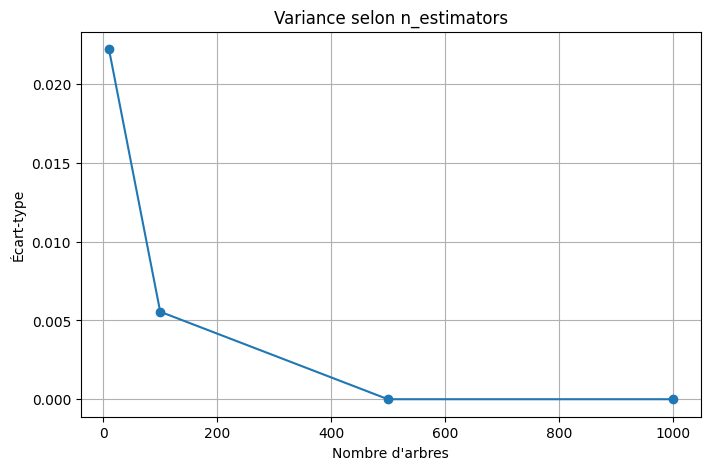

In [11]:
#variance
plt.figure(figsize=(8,5))

plt.plot(
    results_df["n_estimators"],
    results_df["std_accuracy"],
    marker="o"
)

plt.xlabel("Nombre d'arbres")
plt.ylabel("Écart-type")
plt.title("Variance selon n_estimators")

plt.grid(True)

plt.show()

TP 3 : Importance des Variables
Cellule 12 : Dataset Adult Income

In [12]:
#Dataset adult incone
from sklearn.datasets import fetch_openml

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

X = adult.data
y = adult.target

print(X.shape)

(48842, 14)


In [13]:
#pretretment
X = pd.get_dummies(
    X,
    drop_first=True
)

In [14]:
#separation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [15]:
#entrain randomforest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print(
    accuracy_score(
        y_test,
        rf.predict(X_test)
    )
)

0.8600286630724083


In [16]:
#importance gini
gini_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

gini_importance = gini_importance.sort_values(
    by="Importance",
    ascending=False
)

gini_importance.head(15)

,Feature,Importance
1,fnlwgt,0.170843
0,age,0.156816
3,capital-gain,0.093136
5,hours-per-week,0.087310
29,marital-status_Married-civ-spouse,0.085845
2,education-num,0.064845
31,marital-status_Never-married,0.035659
4,capital-loss,0.032073
36,occupation_Exec-managerial,0.017417
47,relationship_Not-in-family,0.016460


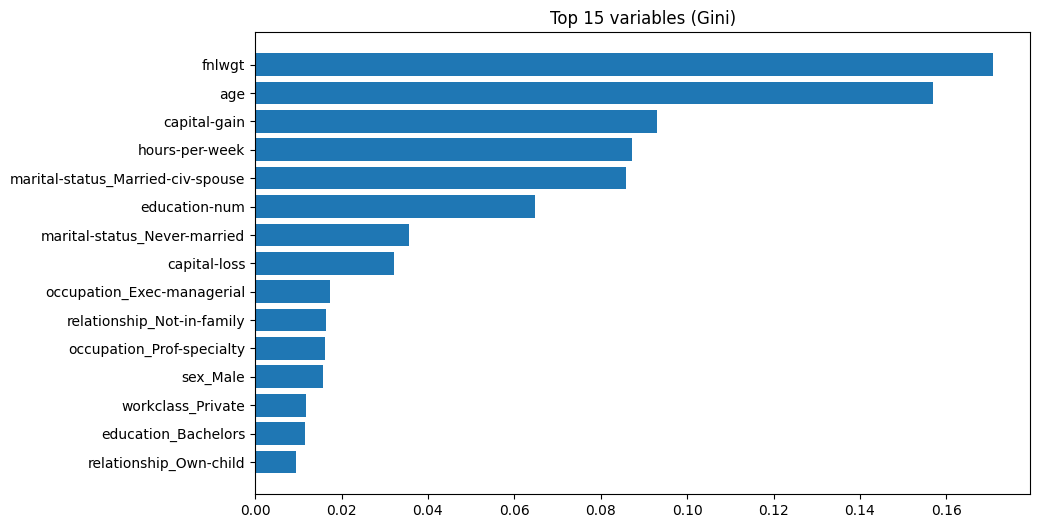

In [22]:
#grahic gini
top_gini = gini_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_gini["Feature"],
    top_gini["Importance"]
)

plt.title(
    "Top 15 variables (Gini)"
)

plt.gca().invert_yaxis()

plt.show()

In [38]:
# =====================================================
# ENTRAINEMENT DE LA RANDOM FOREST
# =====================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy Random Forest :",
      accuracy_score(y_test, pred))

Accuracy Random Forest : 0.860301644714393


In [39]:
# =====================================================
# CALCUL DE L'IMPORTANCE PAR PERMUTATION
# =====================================================

from sklearn.inspection import permutation_importance

# Pour accélérer le calcul, on prend un échantillon
X_test_small = X_test.sample(
    n=2000,
    random_state=42
)

# On récupère les mêmes lignes dans y_test
y_test_small = y_test.loc[X_test_small.index]

# Calcul de l'importance par permutation
perm = permutation_importance(
    estimator=rf,
    X=X_test_small,
    y=y_test_small,
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

print("Calcul terminé avec succès !")

Calcul terminé avec succès !


In [40]:
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.head(10)

,Feature,Importance
3,capital-gain,0.035833
29,marital-status_Married-civ-spouse,0.026333
0,age,0.018000
2,education-num,0.012333
4,capital-loss,0.010000
31,marital-status_Never-married,0.008500
36,occupation_Exec-managerial,0.006500
1,fnlwgt,0.006000
5,hours-per-week,0.005667
56,sex_Male,0.003500


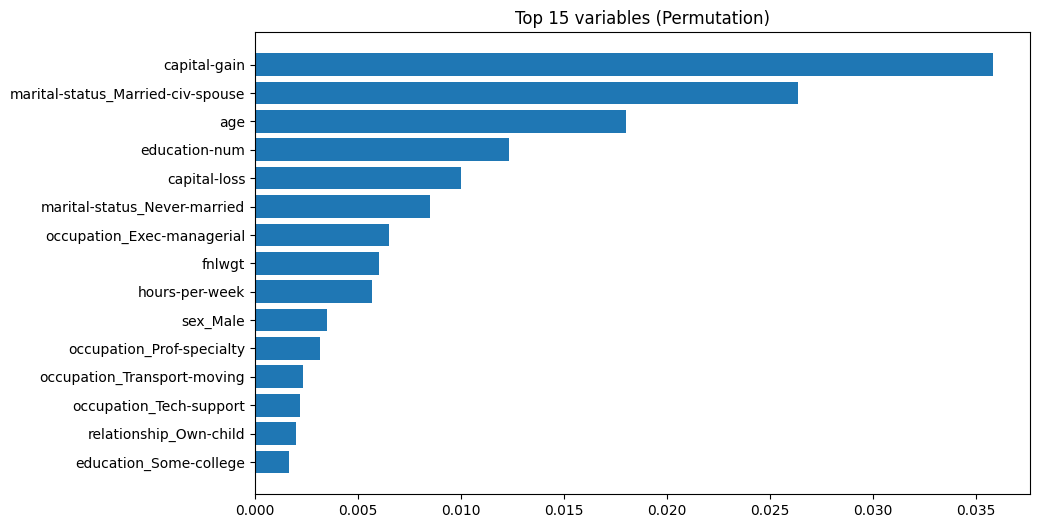

In [41]:
#graphic de permutation
top_perm = perm_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_perm["Feature"],
    top_perm["Importance"]
)

plt.title(
    "Top 15 variables (Permutation)"
)

plt.gca().invert_yaxis()

plt.show()

In [42]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

extra.fit(
    X_train,
    y_train
)

pred = extra.predict(X_test)

print(
    "Accuracy ExtraTrees :",
    accuracy_score(y_test, pred)
)

Accuracy ExtraTrees : 0.8388043404081076
